In [1]:
import yt
import re
import os
import subprocess
from PIL import Image
import astropy.units as u
import astropy.constants as c
import numpy as np
import matplotlib.pyplot as pl

In [199]:
Q = 1e51 * u.s**-1
alpha_B = 2.6e-13 * u.cm**3 / u.s
c_light = c.c
n_H = 4 * np.pi * c_light**3 / (3000 * alpha_B**2 * Q)
r_s = (3 * Q / (4 * np.pi * alpha_B * n_H**2))**(1/3)
t_rec = 1 / (alpha_B * n_H)
n_res = 16
prob_hi = 1.5 * r_s
cell_size = prob_hi / n_res
time_step = 0.15 * cell_size / c_light
t_end = 5 * t_rec
n_step = int(t_end / time_step) + 1
n_H.to(u.cm**-3), r_s.to(u.cm), t_rec.to(u.s), n_step, prob_hi.to(u.cm), t_end.to(u.s), r_s.to(u.pc)

(<Quantity 1669.5676539 1 / cm3>,
 <Quantity 6.9062665e+18 cm>,
 <Quantity 2.30368254e+09 s>,
 3556,
 <Quantity 1.03593997e+19 cm>,
 <Quantity 1.15184127e+10 s>,
 <Quantity 2.23816854 pc>)

In [2]:
class Constants:
    m_p = 1.67353251819e-24
    m_e = 9.10938188e-28
    hplanck = 6.62606957e-27

def e_density(field, data):
    return data['scalar_0'] / Constants.m_e

def HI_density(field, data):
    return data['scalar_1'] / Constants.m_p

def HII_density(field, data):
    return data['scalar_2'] / Constants.m_p

def photon_density(field, data):
    freq_low, freq_high = 3.29e15, 1.50e16
    avg_freq = (freq_low + freq_high) / 2
    return data['radEnergy-Group0'] / (Constants.hplanck * avg_freq)

def x_HI(field, data):
    n_HI = data['scalar_1'] / Constants.m_p
    n_HII = data['scalar_2'] / Constants.m_p
    return n_HI / (n_HI + n_HII)

In [3]:
def create_movie(files, outdir, outname, framerate=5):
    outpath = os.path.join(outdir, f'{outname}.mp4')
    ffmpeg_cmd = [
        'ffmpeg',
        '-y',  # overwrite
        '-f', 'image2pipe',
        '-vcodec', 'png',
        '-framerate', str(framerate),
        '-i', '-',  # input from stdin
        outpath
    ]
    process = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE)
    # Feed images to ffmpeg
    for file in files:
        img = Image.open(file).convert("RGB")  # convert to RGB just in case
        img.save(process.stdin, format='PNG')
    process.stdin.close()
    process.wait()
    print(f"Movie saved to {outpath}")

In [4]:
class StromgrenAnalytical:
    def __init__(self, Q, n_H, alpha_B):
        self.Q = Q
        self.n_H = n_H
        self.alpha_B = alpha_B
        self.r_s = (3 * Q / (4 * np.pi * alpha_B * n_H**2))**(1/3)
        self.t_rec = 1 / (alpha_B * n_H)

In [70]:
class StromgrenSphereSnapshot:
    def __init__(self, path, outdir=None, analytical=None):
        self.path = path
        self.outdir = outdir
        self.analytical = analytical
        self.ds = yt.load(path)
        self.ds.add_field(("boxlib", "n_e"), function=e_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "n_HI"), function=HI_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "n_HII"), function=HII_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "n_photon"), function=photon_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "x_HI"), function=x_HI, units="dimensionless", sampling_type="cell")
        self.ad = self.ds.all_data()
        if self.outdir is None:
            self.outdir = os.path.join(self.path, "plots")
        os.makedirs(self.outdir, exist_ok=True)

    def get_quantity_range(self, field_name):
        field_data = self.ad[field_name]
        vmin, vmax = np.min(field_data), np.max(field_data)
        return vmin, vmax

    def create_quantity_map(self, field_name, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        outpath = os.path.join(self.outdir, f"{field_name}.png")
        if os.path.exists(outpath) and not redo:
            return outpath
        bottom = self.ds.domain_left_edge[2]
        center = self.ds.domain_center.copy()
        center[2] = bottom
        plot = yt.SlicePlot(self.ds, "z", field_name, center=center)
        if vmin is None:
            vmin = 'min'
        if vmax is None:
            vmax = 'max'
        plot.set_zlim(field_name, zmin=vmin, zmax=vmax)
        plot.set_cmap(field_name, cmap)
        plot.set_colorbar_label(field_name, field_name)
        if plot_analytical and self.analytical:
            time = self.ds.current_time.to("s").value
            t_rec = self.analytical.t_rec.to(u.s).value
            r = self.analytical.r_s * (1 - np.exp(-time / t_rec))**(1/3)
            r = r.to(u.pc).value
            plot.annotate_sphere(self.ds.domain_left_edge, radius=(r, "pc"), circle_args={"color": "white", "linewidth": 4})
        plot.save(outpath)
        return outpath

    def create_radiation_map(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        outpath = self.create_quantity_map("n_photon", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        return outpath
    
    def create_scalar0_map(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        outpath = self.create_quantity_map("n_e", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        return outpath
    
    def create_scalar1_map(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        outpath = self.create_quantity_map("n_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        return outpath
    
    def create_scalar2_map(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        outpath = self.create_quantity_map("n_HII", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        return outpath
    
    def create_x_HI_map(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        outpath = self.create_quantity_map("x_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        return outpath

    def create_density_map(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        outpath = self.create_quantity_map("gasDensity", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        return outpath

class StromgrenSphere:
    def __init__(self, path, outdir=None, start_pattern="plt", ending_number=None, step=1, analytical=None):
        self.path = path
        self.outdir = outdir
        self.start_pattern = start_pattern
        self.ending_number = ending_number
        self.step = step
        self.analytical = analytical
        if self.outdir is None:
            self.outdir = os.path.join(self.path, "Plots")
        os.makedirs(self.outdir, exist_ok=True)
        self.plotfile_pathlist = self.get_plotfile_pathlist()
        self.snapshot_list = [StromgenSphereSnapshot(plotfile_path, analytical=self.analytical) for plotfile_path in self.plotfile_pathlist]
        self.time_list = [snapshot.ds.current_time.value for snapshot in self.snapshot_list]

    def get_plotfile_pathlist(self):
        files = [f for f in os.listdir(self.path) if re.match(f"{self.start_pattern}\d+", f)]
        files.sort(key=lambda x: int(re.findall(r'\d+', x)[0]))
        if self.ending_number is not None:
            files = [f for f in files if int(re.findall(r'\d+', f)[0]) <= self.ending_number]
        files = files[::self.step]
        return [os.path.join(self.path, f) for f in files]
    
    def get_quantity_range(self, field_name):
        vmin, vmax = None, None
        for snapshot in self.snapshot_list:
            snapshot_vmin, snapshot_vmax = snapshot.get_quantity_range(field_name)
            if vmin is None:
                vmin, vmax = snapshot_vmin, snapshot_vmax
            else:
                vmin = min(vmin, snapshot_vmin)
                vmax = max(vmax, snapshot_vmax)
        return vmin, vmax
    
    def create_quantity_plots(self, field_name, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        plot_paths = []
        qty_range = self.get_quantity_range(field_name)
        if vmin is None:
            vmin = qty_range[0]
        if vmax is None:
            vmax = qty_range[1]
        for snapshot in self.snapshot_list:
            plot_paths.append(snapshot.create_quantity_map(field_name, vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical))
        return plot_paths

    def create_radiation_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        return self.create_quantity_plots("n_photon", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
    
    def create_scalar0_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        return self.create_quantity_plots("n_e", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
    
    def create_scalar1_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        return self.create_quantity_plots("n_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
    
    def create_scalar2_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        return self.create_quantity_plots("n_HII", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)

    def create_x_HI_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        return self.create_quantity_plots("x_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
    
    def create_density_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        return self.create_quantity_plots("gasDensity", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
    
    def create_radiation_video(self, output_filename="radiation_evolution", fps=10, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        radiation_plot_paths = self.create_radiation_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        create_movie(radiation_plot_paths, self.outdir, output_filename, framerate=fps)

    def create_scalar_videos(self, output_filename_prefix="scalar_evolution", fps=10, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        scalar_plot0_paths = self.create_scalar0_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        scalar_plot1_paths = self.create_scalar1_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        scalar_plot2_paths = self.create_scalar2_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        create_movie(scalar_plot0_paths, self.outdir, f"{output_filename_prefix}_0", framerate=fps)
        create_movie(scalar_plot1_paths, self.outdir, f"{output_filename_prefix}_1", framerate=fps)
        create_movie(scalar_plot2_paths, self.outdir, f"{output_filename_prefix}_2", framerate=fps)

    def create_x_HI_video(self, output_filename="x_HI_evolution", fps=10, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        x_HI_plot_paths = self.create_x_HI_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        create_movie(x_HI_plot_paths, self.outdir, output_filename, framerate=fps)

    def create_density_video(self, output_filename="density_evolution", fps=10, vmin=None, vmax=None, cmap="viridis", redo=False, plot_analytical=False):
        density_plot_paths = self.create_density_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo, plot_analytical=plot_analytical)
        create_movie(density_plot_paths, self.outdir, output_filename, framerate=fps)

### No recombination test

In [ ]:
def get_photon_err(snapshot, snapshot0):
    ds = snapshot.ds
    ad = snapshot.ad
    ad0 = snapshot0.ad
    volume = (ad['dx'][0]**3).value
    n_photon_added = 1e51 * ds.current_time.value / 8.0
    n_photon_inflight = (ad['n_photon'].sum() - ad0['n_photon'].sum()) * volume 
    n_electron_added = (ad['n_e'].sum() - ad0['n_e'].sum()) * volume
    photon_absorbed = n_electron_added
    photon_err = (n_photon_added - (n_photon_inflight + photon_absorbed)) / n_photon_added
    return np.abs(photon_err)

def get_photon_err_history(sphere):
    snapshot0 = sphere.snapshot_list[0]
    errors = []
    for snapshot in sphere.snapshot_list:
        err = get_photon_err(snapshot, snapshot0)
        errors.append(err)
    return errors

def plot_photon_err_history(sphere, fig=None, ax=None, label=None):
    errors = get_photon_err_history(sphere)
    if fig is None or ax is None:
        fig, ax = pl.subplots()
    ax.plot(sphere.time_list, errors, label=label)
    return fig, ax

In [96]:
dirs = ['tol1', 'tol2', 'tol3', 'tol4', 'tol5']
tols = [1e-6, 1e-7, 1e-8, 1e-9, 1e-10]
strm_list = [StromgrenSphere(f"/Users/james471/Desktop/PhD/StarClusters/Code/Sims/StromgrenSphereNoRec/{dir}", step=1, analytical=False) for dir in dirs]

yt : [INFO     ] 2026-03-25 18:18:49,723 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-03-25 18:18:49,723 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-25 18:18:49,724 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-25 18:18:49,724 Parameters: domain_right_edge         = [1.e+19 1.e+19 1.e+19]
yt : [INFO     ] 2026-03-25 18:18:49,810 Parameters: current_time              = 62543267.84965351
yt : [INFO     ] 2026-03-25 18:18:49,810 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-25 18:18:49,811 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-25 18:18:49,811 Parameters: domain_right_edge         = [1.e+19 1.e+19 1.e+19]
yt : [INFO     ] 2026-03-25 18:18:49,889 Parameters: current_time              = 125086535.69930702
yt : [INFO     ] 2026-03-25 18:18:49,889 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-25 18:18:49,890 Paramet

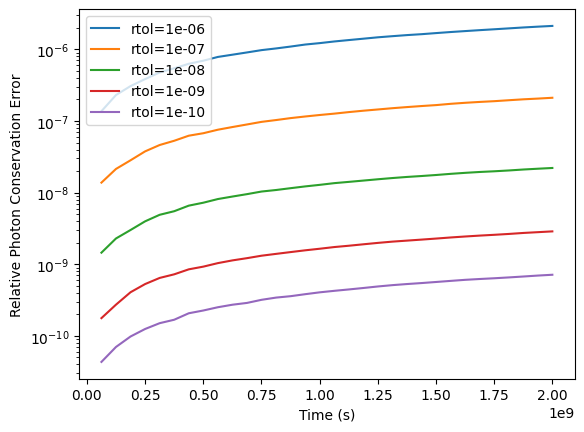

In [104]:
fig, ax = pl.subplots()
for ind, strm in enumerate(strm_list):
    plot_photon_err_history(strm, fig=fig, ax=ax, label=f"rtol={tols[ind]}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Relative Photon Conservation Error")
ax.legend()
ax.set_yscale("log")

### Recombination Test

In [ ]:
analytical = StromgrenAnalytical(1e51 * u.s**-1, 1670 * u.cm**-3, 2.6e-13 * u.cm**3 / u.s)
strm = StromgrenSphere("../../../../Sims/StromgrenSphere/", ending_number=None, step=2, analytical=analytical)
# strm.create_x_HI_video(vmin=None, vmax=None, cmap="plasma", redo=True, plot_analytical=True, fps=5)
# strm.create_radiation_video(vmin=None, vmax=None, cmap="plasma")
# strm.create_scalar_videos(vmin=1e-10, vmax=None, cmap="plasma")
# strm.create_density_video()

In [107]:
n_HII_list = []
t_list = []
for snp in strm.snapshot_list:
    n_HII = snp.ad['n_HII'].sum() * (snp.ad['dx'][0]**3).value
    n_HII_list.append(n_HII)
    t_list.append(snp.ds.current_time.value)

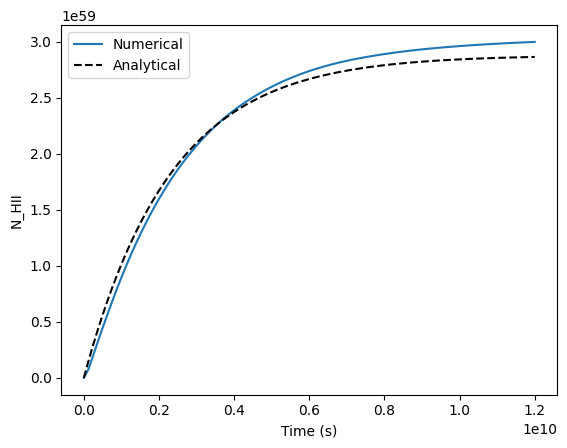

In [112]:
N_eq = 1e51 / (8.0 * 2.6e-13 * 1670)
t_rec = 1 / (2.6e-13 * 1670)
analytical_n_HII_list = [N_eq * (1 - np.exp(-t / t_rec)) for t in t_list]
pl.plot(t_list, n_HII_list, label="Numerical")
pl.plot(t_list, analytical_n_HII_list, color="black", linestyle="dashed", label="Analytical")
pl.xlabel("Time (s)")
pl.ylabel("N_HII")
pl.legend()

In [ ]:
# snp0 = StromgenSphereSnapshot("../../../build/plt0000000")
# ad0 = snp0.ad
analytical = StromgrenAnalytical(1e51 * u.s**-1, 1670 * u.cm**-3, 2.6e-13 * u.cm**3 / u.s)
snp = StromgrenSphereSnapshot("../../../build/plt0000020", analytical=analytical)
# ad = snp.ad
snp.create_x_HI_map(vmin=None, vmax=None, cmap="plasma", redo=True, plot_analytical=True)

yt : [INFO     ] 2026-03-23 15:57:56,151 Parameters: current_time              = 125086535.69930702
yt : [INFO     ] 2026-03-23 15:57:56,151 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-23 15:57:56,152 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-23 15:57:56,152 Parameters: domain_right_edge         = [1.e+19 1.e+19 1.e+19]
yt : [INFO     ] 2026-03-23 15:57:56,188 xlim = 0.000000 10000000000000000000.000000
yt : [INFO     ] 2026-03-23 15:57:56,188 ylim = 0.000000 10000000000000000000.000000
yt : [INFO     ] 2026-03-23 15:57:56,189 xlim = 0.000000 10000000000000000000.000000
yt : [INFO     ] 2026-03-23 15:57:56,190 ylim = 0.000000 10000000000000000000.000000
yt : [INFO     ] 2026-03-23 15:57:56,190 Making a fixed resolution buffer of (('boxlib', 'x_HI')) 800 by 800
yt : [INFO     ] 2026-03-23 15:57:56,345 Saving plot ../../../build/plt0000020/plots/x_HI.png


'../../../build/plt0000020/plots/x_HI.png'